In [2]:
import os

import json
from omegaconf import OmegaConf
import pandas as pd

cfg = OmegaConf.load("../../config/default.yaml")

In [3]:
# Load hf labels
hf_labels = pd.DataFrame()
splits = ['dev_seen', 'dev_unseen', 'test_seen', 'test_unseen', 'train']
for split in splits:
    df_tmp = pd.read_json(f'{cfg.data.paths.hf}/{split}.jsonl', lines=True)
    df_tmp['source'] = split
    hf_labels = pd.concat([hf_labels, df_tmp])
# Only keep labels that have an image
hf_labels = hf_labels[hf_labels['img'].apply(lambda x: os.path.exists(f"{cfg.data.paths.hf}/{x}"))]
# Deduplicate
hf_labels = hf_labels.drop_duplicates(subset=['id'])

In [4]:
# Load annotations
annotations = pd.read_json(f"{cfg.out.hateful_memes_labels}/labels.jsonl", lines=True)
annotations = annotations.drop_duplicates(subset=['id'])
annotations.drop(columns=['img'], inplace=True)
# Binarize labels
annotations['label_incivility'] = annotations['label_incivility'].apply(lambda x: 1 if x > 0 else 0)
annotations['label_intolerance'] = annotations['label_intolerance'].apply(lambda x: 1 if x > 0 else 0)

In [ ]:
# Load predictions
predictions = pd.read_csv(f"{cfg.out.path}/predictions/250708-1815/results.csv")
predictions = predictions.drop_duplicates(subset=['id'])
predictions.drop(columns=['label'], inplace=True)
predictions.rename(columns={"y_pred": "hateful_pred"}, inplace=True)

In [6]:
# Merge hf labels with annotations and predictions
df = pd.merge(hf_labels, annotations, on=["id", "text"], how="left")
df = pd.merge(df, predictions, on=["id"], how="left")

In [7]:
df_annotated = df[df["label_incivility"].notna()].copy()

64327


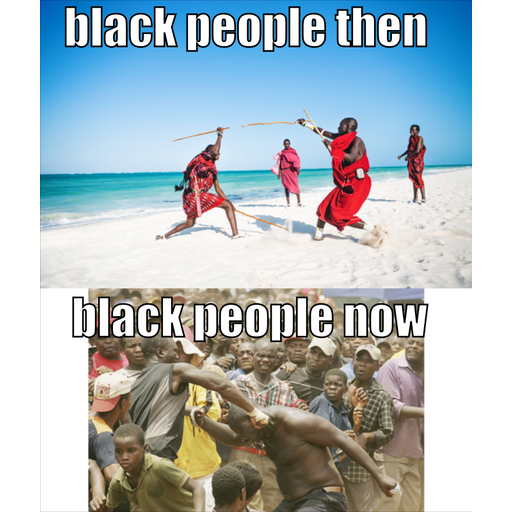

In [12]:
from beyond_hate.data_processing.annotate import *

df = df_annotated[#(df_annotated['label_intolerance'] == 0) &
                  (df_annotated['label_incivility'] == 0) &
                  (df_annotated['label_hateful'] == 1) &
                  (df_annotated['hateful_pred'] == 0)]

for i in range(len(df)):
    row = df.iloc[i]
    img_path = cfg.data.paths.hf + '/' + row['img']
    clear_output(wait=True)
    try:
        print(row['id'])
        display_fixed_image(img_path, size=(512, 512))
    except FileNotFoundError:
        print(f"Image not found: {img_path}")
    
    user_input = input()
    if user_input == '':
        continue
    elif user_input == 'q':
        break

Using df_annotated, I'm interested in looking at biases in incorrect predictions:
- Rude but not hateful: Do incivil (label_incivility = 1) memes have a higher chance of being false positives (label_hateful = 0, hateful_pred = 1)
- Polite but hateful: Do civil (label_incivility = 1) memes have a lower chance of being false negatives (label_hateful = 1, hateful_pred = 1)

In [8]:
# First, let's examine the data structure and create the analysis
import numpy as np

# Create binary prediction columns for easier analysis
df_annotated['is_false_positive'] = (df_annotated['label'] == 0) & (df_annotated['hateful_pred'] == 1)
df_annotated['is_false_negative'] = (df_annotated['label'] == 1) & (df_annotated['hateful_pred'] == 0)

print("Data overview:")
print(f"Total annotated samples: {len(df_annotated)}")
print(f"Incivil samples (label_incivility = 1): {(df_annotated['label_incivility'] == 1).sum()}")
print(f"Civil samples (label_incivility = 0): {(df_annotated['label_incivility'] == 0).sum()}")
print()

# Analysis 1: Rude but not hateful - False Positives
print("=== BIAS ANALYSIS 1: Rude but not hateful (False Positives) ===")
print("Question: Do incivil memes have higher chance of false positives?")
print()

# Filter for non-hateful memes only (label = 0)
non_hateful = df_annotated[df_annotated['label'] == 0].copy()

if len(non_hateful) > 0:
    # False positive rates by civility
    incivil_non_hateful = non_hateful[non_hateful['label_incivility'] == 1]
    civil_non_hateful = non_hateful[non_hateful['label_incivility'] == 0]
    
    incivil_fp_rate = incivil_non_hateful['is_false_positive'].mean() if len(incivil_non_hateful) > 0 else 0
    civil_fp_rate = civil_non_hateful['is_false_positive'].mean() if len(civil_non_hateful) > 0 else 0
    
    print(f"Incivil non-hateful memes (n={len(incivil_non_hateful)}): {incivil_fp_rate:.3f} false positive rate")
    print(f"Civil non-hateful memes (n={len(civil_non_hateful)}): {civil_fp_rate:.3f} false positive rate")
    print(f"Difference: {incivil_fp_rate - civil_fp_rate:.3f}")
    
    if len(incivil_non_hateful) > 0 and len(civil_non_hateful) > 0:
        bias_ratio = incivil_fp_rate / civil_fp_rate if civil_fp_rate > 0 else float('inf')
        print(f"Bias ratio (incivil/civil): {bias_ratio:.2f}x")
        print("Interpretation: Incivil non-hateful memes are" + 
              (f" {bias_ratio:.1f}x more likely" if bias_ratio > 1 else f" {1/bias_ratio:.1f}x less likely") + 
              " to be falsely predicted as hateful")

print("\n" + "="*60 + "\n")

# Analysis 2: Polite but hateful - False Negatives  
print("=== BIAS ANALYSIS 2: Polite but hateful (False Negatives) ===")
print("Question: Do civil memes have higher chance of false negatives?")
print()

# Filter for hateful memes only (label = 1)
hateful = df_annotated[df_annotated['label'] == 1].copy()

if len(hateful) > 0:
    # False negative rates by civility
    civil_hateful = hateful[hateful['label_incivility'] == 0]
    incivil_hateful = hateful[hateful['label_incivility'] == 1]
    
    civil_fn_rate = civil_hateful['is_false_negative'].mean() if len(civil_hateful) > 0 else 0
    incivil_fn_rate = incivil_hateful['is_false_negative'].mean() if len(incivil_hateful) > 0 else 0
    
    print(f"Civil hateful memes (n={len(civil_hateful)}): {civil_fn_rate:.3f} false negative rate")
    print(f"Incivil hateful memes (n={len(incivil_hateful)}): {incivil_fn_rate:.3f} false negative rate")
    print(f"Difference: {civil_fn_rate - incivil_fn_rate:.3f}")
    
    if len(civil_hateful) > 0 and len(incivil_hateful) > 0:
        bias_ratio = civil_fn_rate / incivil_fn_rate if incivil_fn_rate > 0 else float('inf')
        print(f"Bias ratio (civil/incivil): {bias_ratio:.2f}x")
        print("Interpretation: Civil hateful memes are" + 
              (f" {bias_ratio:.1f}x more likely" if bias_ratio > 1 else f" {1/bias_ratio:.1f}x less likely") + 
              " to be missed (false negatives)")

print("\n" + "="*60 + "\n")

# Summary crosstab analysis
print("=== DETAILED BREAKDOWN ===")
print("\nCrosstab: Incivility vs Hate Label vs Prediction")
crosstab = pd.crosstab([df_annotated['label_incivility'], df_annotated['label']], 
                       df_annotated['hateful_pred'], 
                       margins=True)
print(crosstab)

Data overview:
Total annotated samples: 604
Incivil samples (label_incivility = 1): 295
Civil samples (label_incivility = 0): 309

=== BIAS ANALYSIS 1: Rude but not hateful (False Positives) ===
Question: Do incivil memes have higher chance of false positives?

Incivil non-hateful memes (n=93): 0.161 false positive rate
Civil non-hateful memes (n=228): 0.136 false positive rate
Difference: 0.025
Bias ratio (incivil/civil): 1.19x
Interpretation: Incivil non-hateful memes are 1.2x more likely to be falsely predicted as hateful


=== BIAS ANALYSIS 2: Polite but hateful (False Negatives) ===
Question: Do civil memes have higher chance of false negatives?

Civil hateful memes (n=81): 0.235 false negative rate
Incivil hateful memes (n=202): 0.119 false negative rate
Difference: 0.116
Bias ratio (civil/incivil): 1.97x
Interpretation: Civil hateful memes are 2.0x more likely to be missed (false negatives)


=== DETAILED BREAKDOWN ===

Crosstab: Incivility vs Hate Label vs Prediction
hateful_pr

In [9]:
# Statistical significance testing for bias analysis
from scipy.stats import chi2_contingency, fisher_exact
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

print("=== STATISTICAL SIGNIFICANCE TESTS ===\n")

# Test 1: False Positive Bias (Incivil vs Civil in Non-Hateful memes)
print("1. FALSE POSITIVE BIAS TEST")
print("H0: No difference in false positive rates between incivil and civil non-hateful memes")

non_hateful = df_annotated[df_annotated['label'] == 0].copy()
incivil_non_hateful = non_hateful[non_hateful['label_incivility'] == 1]
civil_non_hateful = non_hateful[non_hateful['label_incivility'] == 0]

if len(incivil_non_hateful) > 0 and len(civil_non_hateful) > 0:
    # Count successes (false positives) and totals
    fp_incivil = incivil_non_hateful['is_false_positive'].sum()
    total_incivil = len(incivil_non_hateful)
    fp_civil = civil_non_hateful['is_false_positive'].sum()
    total_civil = len(civil_non_hateful)
    
    print(f"Incivil: {fp_incivil}/{total_incivil} false positives")
    print(f"Civil: {fp_civil}/{total_civil} false positives")
    
    # Two-proportion z-test
    counts = np.array([fp_incivil, fp_civil])
    nobs = np.array([total_incivil, total_civil])
    z_stat, p_value_z = proportions_ztest(counts, nobs)
    
    print(f"Two-proportion z-test: z={z_stat:.3f}, p={p_value_z:.4f}")
    
    # Fisher's exact test (more robust for small samples)
    # Create 2x2 contingency table
    contingency_fp = np.array([
        [fp_incivil, total_incivil - fp_incivil],  # incivil: FP, not FP
        [fp_civil, total_civil - fp_civil]        # civil: FP, not FP
    ])
    
    odds_ratio, p_value_fisher = fisher_exact(contingency_fp)
    print(f"Fisher's exact test: OR={odds_ratio:.3f}, p={p_value_fisher:.4f}")
    
    # Chi-square test
    chi2, p_value_chi2, dof, expected = chi2_contingency(contingency_fp)
    print(f"Chi-square test: χ²={chi2:.3f}, p={p_value_chi2:.4f}")
    
    print(f"Significance: {'YES' if min(p_value_z, p_value_fisher, p_value_chi2) < 0.05 else 'NO'} (α=0.05)")

print("\n" + "-"*50 + "\n")

# Test 2: False Negative Bias (Civil vs Incivil in Hateful memes)
print("2. FALSE NEGATIVE BIAS TEST")
print("H0: No difference in false negative rates between civil and incivil hateful memes")

hateful = df_annotated[df_annotated['label'] == 1].copy()
civil_hateful = hateful[hateful['label_incivility'] == 0]
incivil_hateful = hateful[hateful['label_incivility'] == 1]

if len(civil_hateful) > 0 and len(incivil_hateful) > 0:
    # Count successes (false negatives) and totals
    fn_civil = civil_hateful['is_false_negative'].sum()
    total_civil_h = len(civil_hateful)
    fn_incivil = incivil_hateful['is_false_negative'].sum()
    total_incivil_h = len(incivil_hateful)
    
    print(f"Civil: {fn_civil}/{total_civil_h} false negatives")
    print(f"Incivil: {fn_incivil}/{total_incivil_h} false negatives")
    
    # Two-proportion z-test
    counts = np.array([fn_civil, fn_incivil])
    nobs = np.array([total_civil_h, total_incivil_h])
    z_stat, p_value_z = proportions_ztest(counts, nobs)
    
    print(f"Two-proportion z-test: z={z_stat:.3f}, p={p_value_z:.4f}")
    
    # Fisher's exact test
    contingency_fn = np.array([
        [fn_civil, total_civil_h - fn_civil],      # civil: FN, not FN
        [fn_incivil, total_incivil_h - fn_incivil] # incivil: FN, not FN
    ])
    
    odds_ratio, p_value_fisher = fisher_exact(contingency_fn)
    print(f"Fisher's exact test: OR={odds_ratio:.3f}, p={p_value_fisher:.4f}")
    
    # Chi-square test
    chi2, p_value_chi2, dof, expected = chi2_contingency(contingency_fn)
    print(f"Chi-square test: χ²={chi2:.3f}, p={p_value_chi2:.4f}")
    
    print(f"Significance: {'YES' if min(p_value_z, p_value_fisher, p_value_chi2) < 0.05 else 'NO'} (α=0.05)")

print("\n" + "-"*50 + "\n")

# Test 3: Overall bias test using the full crosstab
print("3. OVERALL ASSOCIATION TEST")
print("H0: No association between incivility and prediction errors")

# Create full contingency table: (incivility, true_label) vs prediction
full_crosstab = pd.crosstab([df_annotated['label_incivility'], df_annotated['label']], 
                           df_annotated['hateful_pred'])

chi2_full, p_value_full, dof_full, expected_full = chi2_contingency(full_crosstab.values)
print(f"Full contingency table chi-square: χ²={chi2_full:.3f}, p={p_value_full:.4f}, df={dof_full}")
print(f"Overall association: {'SIGNIFICANT' if p_value_full < 0.05 else 'NOT SIGNIFICANT'} (α=0.05)")

print("\n=== INTERPRETATION GUIDE ===")
print("p < 0.001: Very strong evidence against H0 (***)")
print("p < 0.01:  Strong evidence against H0 (**)")
print("p < 0.05:  Moderate evidence against H0 (*)")
print("p ≥ 0.05:  Insufficient evidence against H0 (ns)")

print("\n=== RECOMMENDED TESTS ===")
print("• Fisher's exact test: Most robust, especially for small samples")
print("• Two-proportion z-test: Good for larger samples (n>30 per group)")
print("• Chi-square test: Requires expected frequencies ≥5 in all cells")

=== STATISTICAL SIGNIFICANCE TESTS ===

1. FALSE POSITIVE BIAS TEST
H0: No difference in false positive rates between incivil and civil non-hateful memes
Incivil: 15/93 false positives
Civil: 31/228 false positives
Two-proportion z-test: z=0.587, p=0.5569
Fisher's exact test: OR=1.222, p=0.5993
Chi-square test: χ²=0.170, p=0.6804
Significance: NO (α=0.05)

--------------------------------------------------

2. FALSE NEGATIVE BIAS TEST
H0: No difference in false negative rates between civil and incivil hateful memes
Civil: 19/81 false negatives
Incivil: 24/202 false negatives
Two-proportion z-test: z=2.452, p=0.0142
Fisher's exact test: OR=2.273, p=0.0176
Chi-square test: χ²=5.147, p=0.0233
Significance: YES (α=0.05)

--------------------------------------------------

3. OVERALL ASSOCIATION TEST
H0: No association between incivility and prediction errors
Full contingency table chi-square: χ²=302.925, p=0.0000, df=3
Overall association: SIGNIFICANT (α=0.05)

=== INTERPRETATION GUIDE ===

In [10]:
full_crosstab = pd.crosstab([df_annotated['label_incivility'], df_annotated['label']], 
                           df_annotated['hateful_pred'])

In [11]:
# Bias analysis using label_intolerance
print("=== INTOLERANCE BIAS ANALYSIS ===\n")

# Create binary prediction columns for easier analysis (if not already created)
if 'is_false_positive' not in df_annotated.columns:
    df_annotated['is_false_positive'] = (df_annotated['label'] == 0) & (df_annotated['hateful_pred'] == 1)
    df_annotated['is_false_negative'] = (df_annotated['label'] == 1) & (df_annotated['hateful_pred'] == 0)

print("Data overview:")
print(f"Total annotated samples: {len(df_annotated)}")
print(f"Intolerant samples (label_intolerance = 1): {(df_annotated['label_intolerance'] == 1).sum()}")
print(f"Tolerant samples (label_intolerance = 0): {(df_annotated['label_intolerance'] == 0).sum()}")
print()

# Analysis 1: Intolerant but not hateful - False Positives
print("=== BIAS ANALYSIS 1: Intolerant but not hateful (False Positives) ===")
print("Question: Do intolerant memes have higher chance of false positives?")
print()

# Filter for non-hateful memes only (label = 0)
non_hateful = df_annotated[df_annotated['label'] == 0].copy()

if len(non_hateful) > 0:
    # False positive rates by tolerance
    intolerant_non_hateful = non_hateful[non_hateful['label_intolerance'] == 1]
    tolerant_non_hateful = non_hateful[non_hateful['label_intolerance'] == 0]
    
    intolerant_fp_rate = intolerant_non_hateful['is_false_positive'].mean() if len(intolerant_non_hateful) > 0 else 0
    tolerant_fp_rate = tolerant_non_hateful['is_false_positive'].mean() if len(tolerant_non_hateful) > 0 else 0
    
    print(f"Intolerant non-hateful memes (n={len(intolerant_non_hateful)}): {intolerant_fp_rate:.3f} false positive rate")
    print(f"Tolerant non-hateful memes (n={len(tolerant_non_hateful)}): {tolerant_fp_rate:.3f} false positive rate")
    print(f"Difference: {intolerant_fp_rate - tolerant_fp_rate:.3f}")
    
    if len(intolerant_non_hateful) > 0 and len(tolerant_non_hateful) > 0:
        bias_ratio = intolerant_fp_rate / tolerant_fp_rate if tolerant_fp_rate > 0 else float('inf')
        print(f"Bias ratio (intolerant/tolerant): {bias_ratio:.2f}x")
        print("Interpretation: Intolerant non-hateful memes are" + 
              (f" {bias_ratio:.1f}x more likely" if bias_ratio > 1 else f" {1/bias_ratio:.1f}x less likely") + 
              " to be falsely predicted as hateful")

print("\n" + "="*60 + "\n")

# Analysis 2: Tolerant but hateful - False Negatives  
print("=== BIAS ANALYSIS 2: Tolerant but hateful (False Negatives) ===")
print("Question: Do tolerant memes have higher chance of false negatives?")
print()

# Filter for hateful memes only (label = 1)
hateful = df_annotated[df_annotated['label'] == 1].copy()

if len(hateful) > 0:
    # False negative rates by tolerance
    tolerant_hateful = hateful[hateful['label_intolerance'] == 0]
    intolerant_hateful = hateful[hateful['label_intolerance'] == 1]
    
    tolerant_fn_rate = tolerant_hateful['is_false_negative'].mean() if len(tolerant_hateful) > 0 else 0
    intolerant_fn_rate = intolerant_hateful['is_false_negative'].mean() if len(intolerant_hateful) > 0 else 0
    
    print(f"Tolerant hateful memes (n={len(tolerant_hateful)}): {tolerant_fn_rate:.3f} false negative rate")
    print(f"Intolerant hateful memes (n={len(intolerant_hateful)}): {intolerant_fn_rate:.3f} false negative rate")
    print(f"Difference: {tolerant_fn_rate - intolerant_fn_rate:.3f}")
    
    if len(tolerant_hateful) > 0 and len(intolerant_hateful) > 0:
        bias_ratio = tolerant_fn_rate / intolerant_fn_rate if intolerant_fn_rate > 0 else float('inf')
        print(f"Bias ratio (tolerant/intolerant): {bias_ratio:.2f}x")
        print("Interpretation: Tolerant hateful memes are" + 
              (f" {bias_ratio:.1f}x more likely" if bias_ratio > 1 else f" {1/bias_ratio:.1f}x less likely") + 
              " to be missed (false negatives)")

print("\n" + "="*60 + "\n")

# Summary crosstab analysis
print("=== DETAILED BREAKDOWN ===")
print("\nCrosstab: Intolerance vs Hate Label vs Prediction")
crosstab_intolerance = pd.crosstab([df_annotated['label_intolerance'], df_annotated['label']], 
                                  df_annotated['hateful_pred'], 
                                  margins=True)
print(crosstab_intolerance)

=== INTOLERANCE BIAS ANALYSIS ===

Data overview:
Total annotated samples: 604
Intolerant samples (label_intolerance = 1): 274
Tolerant samples (label_intolerance = 0): 330

=== BIAS ANALYSIS 1: Intolerant but not hateful (False Positives) ===
Question: Do intolerant memes have higher chance of false positives?

Intolerant non-hateful memes (n=32): 0.281 false positive rate
Tolerant non-hateful memes (n=289): 0.128 false positive rate
Difference: 0.153
Bias ratio (intolerant/tolerant): 2.20x
Interpretation: Intolerant non-hateful memes are 2.2x more likely to be falsely predicted as hateful


=== BIAS ANALYSIS 2: Tolerant but hateful (False Negatives) ===
Question: Do tolerant memes have higher chance of false negatives?

Tolerant hateful memes (n=41): 0.171 false negative rate
Intolerant hateful memes (n=242): 0.149 false negative rate
Difference: 0.022
Bias ratio (tolerant/intolerant): 1.15x
Interpretation: Tolerant hateful memes are 1.1x more likely to be missed (false negatives)




In [12]:
# Statistical significance testing for intolerance bias analysis
from scipy.stats import chi2_contingency, fisher_exact
from statsmodels.stats.proportion import proportions_ztest
import numpy as np

print("\n=== INTOLERANCE STATISTICAL SIGNIFICANCE TESTS ===\n")

# Test 1: False Positive Bias (Intolerant vs Tolerant in Non-Hateful memes)
print("1. FALSE POSITIVE BIAS TEST (INTOLERANCE)")
print("H0: No difference in false positive rates between intolerant and tolerant non-hateful memes")

non_hateful = df_annotated[df_annotated['label'] == 0].copy()
intolerant_non_hateful = non_hateful[non_hateful['label_intolerance'] == 1]
tolerant_non_hateful = non_hateful[non_hateful['label_intolerance'] == 0]

if len(intolerant_non_hateful) > 0 and len(tolerant_non_hateful) > 0:
    # Count successes (false positives) and totals
    fp_intolerant = intolerant_non_hateful['is_false_positive'].sum()
    total_intolerant = len(intolerant_non_hateful)
    fp_tolerant = tolerant_non_hateful['is_false_positive'].sum()
    total_tolerant = len(tolerant_non_hateful)
    
    print(f"Intolerant: {fp_intolerant}/{total_intolerant} false positives")
    print(f"Tolerant: {fp_tolerant}/{total_tolerant} false positives")
    
    # Two-proportion z-test
    counts = np.array([fp_intolerant, fp_tolerant])
    nobs = np.array([total_intolerant, total_tolerant])
    z_stat, p_value_z = proportions_ztest(counts, nobs)
    
    print(f"Two-proportion z-test: z={z_stat:.3f}, p={p_value_z:.4f}")
    
    # Fisher's exact test (more robust for small samples)
    # Create 2x2 contingency table
    contingency_fp = np.array([
        [fp_intolerant, total_intolerant - fp_intolerant],  # intolerant: FP, not FP
        [fp_tolerant, total_tolerant - fp_tolerant]        # tolerant: FP, not FP
    ])
    
    odds_ratio, p_value_fisher = fisher_exact(contingency_fp)
    print(f"Fisher's exact test: OR={odds_ratio:.3f}, p={p_value_fisher:.4f}")
    
    # Chi-square test
    chi2, p_value_chi2, dof, expected = chi2_contingency(contingency_fp)
    print(f"Chi-square test: χ²={chi2:.3f}, p={p_value_chi2:.4f}")
    
    print(f"Significance: {'YES' if min(p_value_z, p_value_fisher, p_value_chi2) < 0.05 else 'NO'} (α=0.05)")

print("\n" + "-"*50 + "\n")

# Test 2: False Negative Bias (Tolerant vs Intolerant in Hateful memes)
print("2. FALSE NEGATIVE BIAS TEST (INTOLERANCE)")
print("H0: No difference in false negative rates between tolerant and intolerant hateful memes")

hateful = df_annotated[df_annotated['label'] == 1].copy()
tolerant_hateful = hateful[hateful['label_intolerance'] == 0]
intolerant_hateful = hateful[hateful['label_intolerance'] == 1]

if len(tolerant_hateful) > 0 and len(intolerant_hateful) > 0:
    # Count successes (false negatives) and totals
    fn_tolerant = tolerant_hateful['is_false_negative'].sum()
    total_tolerant_h = len(tolerant_hateful)
    fn_intolerant = intolerant_hateful['is_false_negative'].sum()
    total_intolerant_h = len(intolerant_hateful)
    
    print(f"Tolerant: {fn_tolerant}/{total_tolerant_h} false negatives")
    print(f"Intolerant: {fn_intolerant}/{total_intolerant_h} false negatives")
    
    # Two-proportion z-test
    counts = np.array([fn_tolerant, fn_intolerant])
    nobs = np.array([total_tolerant_h, total_intolerant_h])
    z_stat, p_value_z = proportions_ztest(counts, nobs)
    
    print(f"Two-proportion z-test: z={z_stat:.3f}, p={p_value_z:.4f}")
    
    # Fisher's exact test
    contingency_fn = np.array([
        [fn_tolerant, total_tolerant_h - fn_tolerant],      # tolerant: FN, not FN
        [fn_intolerant, total_intolerant_h - fn_intolerant] # intolerant: FN, not FN
    ])
    
    odds_ratio, p_value_fisher = fisher_exact(contingency_fn)
    print(f"Fisher's exact test: OR={odds_ratio:.3f}, p={p_value_fisher:.4f}")
    
    # Chi-square test
    chi2, p_value_chi2, dof, expected = chi2_contingency(contingency_fn)
    print(f"Chi-square test: χ²={chi2:.3f}, p={p_value_chi2:.4f}")
    
    print(f"Significance: {'YES' if min(p_value_z, p_value_fisher, p_value_chi2) < 0.05 else 'NO'} (α=0.05)")

print("\n" + "-"*50 + "\n")

# Test 3: Overall bias test using the full crosstab
print("3. OVERALL ASSOCIATION TEST (INTOLERANCE)")
print("H0: No association between intolerance and prediction errors")

# Create full contingency table: (intolerance, true_label) vs prediction
full_crosstab_intolerance = pd.crosstab([df_annotated['label_intolerance'], df_annotated['label']], 
                                       df_annotated['hateful_pred'])

chi2_full, p_value_full, dof_full, expected_full = chi2_contingency(full_crosstab_intolerance.values)
print(f"Full contingency table chi-square: χ²={chi2_full:.3f}, p={p_value_full:.4f}, df={dof_full}")
print(f"Overall association: {'SIGNIFICANT' if p_value_full < 0.05 else 'NOT SIGNIFICANT'} (α=0.05)")

print("\n=== COMPARISON: CIVILITY vs INTOLERANCE BIAS ===")
print("Compare the bias ratios and significance levels between:")
print("• Civility bias (incivil vs civil)")
print("• Intolerance bias (intolerant vs tolerant)")
print("This will help you understand which dimension shows stronger bias patterns.")


=== INTOLERANCE STATISTICAL SIGNIFICANCE TESTS ===

1. FALSE POSITIVE BIAS TEST (INTOLERANCE)
H0: No difference in false positive rates between intolerant and tolerant non-hateful memes
Intolerant: 9/32 false positives
Tolerant: 37/289 false positives
Two-proportion z-test: z=2.347, p=0.0189
Fisher's exact test: OR=2.665, p=0.0301
Chi-square test: χ²=4.332, p=0.0374
Significance: YES (α=0.05)

--------------------------------------------------

2. FALSE NEGATIVE BIAS TEST (INTOLERANCE)
H0: No difference in false negative rates between tolerant and intolerant hateful memes
Tolerant: 7/41 false negatives
Intolerant: 36/242 false negatives
Two-proportion z-test: z=0.362, p=0.7170
Fisher's exact test: OR=1.178, p=0.6462
Chi-square test: χ²=0.016, p=0.8988
Significance: NO (α=0.05)

--------------------------------------------------

3. OVERALL ASSOCIATION TEST (INTOLERANCE)
H0: No association between intolerance and prediction errors
Full contingency table chi-square: χ²=302.429, p=0.0000

Lets now just compare the ground truth labels. I want to explore if the concept of hatefulness is composed out of intolerance and/or incivility 

In [14]:
# Simplified hypothesis testing with correlations
print("=== SIMPLIFIED HYPOTHESIS TESTING ===\n")

total_samples = len(df_annotated)

# Hypothesis 1: Hatefulness = Intolerance
print("HYPOTHESIS 1: Hatefulness = Intolerance")
perfect_match_h1 = (df_annotated['label'] == df_annotated['label_intolerance']).sum()
match_rate_h1 = perfect_match_h1 / total_samples
corr_h1 = df_annotated['label'].corr(df_annotated['label_intolerance'])
print(f"Perfect matches: {perfect_match_h1}/{total_samples} ({match_rate_h1*100:.1f}%)")
print(f"Correlation: r={corr_h1:.3f}")

# Statistical test
intolerance_confusion = pd.crosstab(df_annotated['label_intolerance'], df_annotated['label'])
chi2_h1, p_h1, _, _ = chi2_contingency(intolerance_confusion)
print(f"Chi-square test: χ²={chi2_h1:.3f}, p={p_h1:.4f}")

print("\n" + "-"*50 + "\n")

# Hypothesis 2: Hatefulness = (Incivil OR Intolerant)
print("HYPOTHESIS 2: Hatefulness = (Incivil OR Intolerant)")
df_annotated['incivil_or_intolerant'] = ((df_annotated['label_incivility'] == 1) | 
                                        (df_annotated['label_intolerance'] == 1)).astype(int)

perfect_match_h2 = (df_annotated['label'] == df_annotated['incivil_or_intolerant']).sum()
match_rate_h2 = perfect_match_h2 / total_samples
corr_h2 = df_annotated['label'].corr(df_annotated['incivil_or_intolerant'])
print(f"Perfect matches: {perfect_match_h2}/{total_samples} ({match_rate_h2*100:.1f}%)")
print(f"Correlation: r={corr_h2:.3f}")

# Statistical test
composite_confusion = pd.crosstab(df_annotated['incivil_or_intolerant'], df_annotated['label'])
chi2_h2, p_h2, _, _ = chi2_contingency(composite_confusion)
print(f"Chi-square test: χ²={chi2_h2:.3f}, p={p_h2:.4f}")

print("\n" + "="*50 + "\n")

# Summary
print("SUMMARY:")
print(f"H1 (Intolerance only): {match_rate_h1*100:.1f}% match, r={corr_h1:.3f}, p={p_h1:.4f}")
print(f"H2 (Incivil OR Intolerant): {match_rate_h2*100:.1f}% match, r={corr_h2:.3f}, p={p_h2:.4f}")
print(f"Better hypothesis: {'H2' if match_rate_h2 > match_rate_h1 else 'H1'}")
print(f"Both significant: {'YES' if min(p_h1, p_h2) < 0.05 else 'NO'}")

=== SIMPLIFIED HYPOTHESIS TESTING ===

HYPOTHESIS 1: Hatefulness = Intolerance
Perfect matches: 531/604 (87.9%)
Correlation: r=0.757
Chi-square test: χ²=343.263, p=0.0000

--------------------------------------------------

HYPOTHESIS 2: Hatefulness = (Incivil OR Intolerant)
Perfect matches: 490/604 (81.1%)
Correlation: r=0.655
Chi-square test: χ²=256.830, p=0.0000


SUMMARY:
H1 (Intolerance only): 87.9% match, r=0.757, p=0.0000
H2 (Incivil OR Intolerant): 81.1% match, r=0.655, p=0.0000
Better hypothesis: H1
Both significant: YES


In [15]:
# Simplified hypothesis testing with correlations and conditional probabilities
print("=== SIMPLIFIED HYPOTHESIS TESTING ===\n")

total_samples = len(df_annotated)

# Hypothesis 1: Hatefulness = Intolerance
print("HYPOTHESIS 1: Hatefulness = Intolerance")
perfect_match_h1 = (df_annotated['label'] == df_annotated['label_intolerance']).sum()
match_rate_h1 = perfect_match_h1 / total_samples
corr_h1 = df_annotated['label'].corr(df_annotated['label_intolerance'])

# Conditional probabilities
p_hateful_given_intolerant = df_annotated[df_annotated['label_intolerance'] == 1]['label'].mean()
p_hateful_given_tolerant = df_annotated[df_annotated['label_intolerance'] == 0]['label'].mean()

print(f"Perfect matches: {perfect_match_h1}/{total_samples} ({match_rate_h1*100:.1f}%)")
print(f"Correlation: r={corr_h1:.3f}")
print(f"P(Hateful | Intolerant): {p_hateful_given_intolerant:.3f}")
print(f"P(Hateful | Tolerant): {p_hateful_given_tolerant:.3f}")

# Statistical test
intolerance_confusion = pd.crosstab(df_annotated['label_intolerance'], df_annotated['label'])
chi2_h1, p_h1, _, _ = chi2_contingency(intolerance_confusion)
print(f"Chi-square test: χ²={chi2_h1:.3f}, p={p_h1:.4f}")

print("\n" + "-"*50 + "\n")

# Hypothesis 2: Hatefulness = (Incivil OR Intolerant)
print("HYPOTHESIS 2: Hatefulness = (Incivil OR Intolerant)")
df_annotated['incivil_or_intolerant'] = ((df_annotated['label_incivility'] == 1) | 
                                        (df_annotated['label_intolerance'] == 1)).astype(int)

perfect_match_h2 = (df_annotated['label'] == df_annotated['incivil_or_intolerant']).sum()
match_rate_h2 = perfect_match_h2 / total_samples
corr_h2 = df_annotated['label'].corr(df_annotated['incivil_or_intolerant'])

# Conditional probabilities
p_hateful_given_incivil = df_annotated[df_annotated['label_incivility'] == 1]['label'].mean()
p_hateful_given_civil = df_annotated[df_annotated['label_incivility'] == 0]['label'].mean()
p_hateful_given_incivil_or_intolerant = df_annotated[df_annotated['incivil_or_intolerant'] == 1]['label'].mean()
p_hateful_given_civil_and_tolerant = df_annotated[df_annotated['incivil_or_intolerant'] == 0]['label'].mean()

# The key probability you asked for
p_not_hateful_given_civil_and_tolerant = 1 - p_hateful_given_civil_and_tolerant

print(f"Perfect matches: {perfect_match_h2}/{total_samples} ({match_rate_h2*100:.1f}%)")
print(f"Correlation: r={corr_h2:.3f}")
print(f"P(Hateful | Incivil): {p_hateful_given_incivil:.3f}")
print(f"P(Hateful | Civil): {p_hateful_given_civil:.3f}")
print(f"P(Hateful | Incivil OR Intolerant): {p_hateful_given_incivil_or_intolerant:.3f}")
print(f"P(Hateful | Civil AND Tolerant): {p_hateful_given_civil_and_tolerant:.3f}")
print(f"P(NOT Hateful | Civil AND Tolerant): {p_not_hateful_given_civil_and_tolerant:.3f}")

# Statistical test
composite_confusion = pd.crosstab(df_annotated['incivil_or_intolerant'], df_annotated['label'])
chi2_h2, p_h2, _, _ = chi2_contingency(composite_confusion)
print(f"Chi-square test: χ²={chi2_h2:.3f}, p={p_h2:.4f}")

print("\n" + "="*50 + "\n")

# Summary
print("SUMMARY:")
print(f"H1 (Intolerance only): {match_rate_h1*100:.1f}% match, r={corr_h1:.3f}, p={p_h1:.4f}")
print(f"H2 (Incivil OR Intolerant): {match_rate_h2*100:.1f}% match, r={corr_h2:.3f}, p={p_h2:.4f}")
print(f"Better hypothesis: {'H2' if match_rate_h2 > match_rate_h1 else 'H1'}")
print(f"Both significant: {'YES' if min(p_h1, p_h2) < 0.05 else 'NO'}")

print("\n=== CONDITIONAL PROBABILITY INSIGHTS ===")
print("Key insights:")
print(f"• Intolerant content is {p_hateful_given_intolerant:.1%} likely to be hateful")
print(f"• Incivil content is {p_hateful_given_incivil:.1%} likely to be hateful")
print(f"• Content that is incivil OR intolerant is {p_hateful_given_incivil_or_intolerant:.1%} likely to be hateful")
print(f"• Content that is civil AND tolerant is {p_hateful_given_civil_and_tolerant:.1%} likely to be hateful")
print(f"• Content that is civil AND tolerant is {p_not_hateful_given_civil_and_tolerant:.1%} likely to be NOT hateful")

=== SIMPLIFIED HYPOTHESIS TESTING ===

HYPOTHESIS 1: Hatefulness = Intolerance
Perfect matches: 531/604 (87.9%)
Correlation: r=0.757
P(Hateful | Intolerant): 0.883
P(Hateful | Tolerant): 0.124
Chi-square test: χ²=343.263, p=0.0000

--------------------------------------------------

HYPOTHESIS 2: Hatefulness = (Incivil OR Intolerant)
Perfect matches: 490/604 (81.1%)
Correlation: r=0.655
P(Hateful | Incivil): 0.685
P(Hateful | Civil): 0.262
P(Hateful | Incivil OR Intolerant): 0.728
P(Hateful | Civil AND Tolerant): 0.056
P(NOT Hateful | Civil AND Tolerant): 0.944
Chi-square test: χ²=256.830, p=0.0000


SUMMARY:
H1 (Intolerance only): 87.9% match, r=0.757, p=0.0000
H2 (Incivil OR Intolerant): 81.1% match, r=0.655, p=0.0000
Better hypothesis: H1
Both significant: YES

=== CONDITIONAL PROBABILITY INSIGHTS ===
Key insights:
• Intolerant content is 88.3% likely to be hateful
• Incivil content is 68.5% likely to be hateful
• Content that is incivil OR intolerant is 72.8% likely to be hateful
•